In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl


from PyAstronomy import pyasl
import pysynphot as S

from matplotlib.patches import Ellipse

import re

import pandas as pd

from astropy.time import Time

from astroquery.gaia import Gaia
from astroquery.utils.tap.core import TapPlus
from dust_extinction.parameter_averages import G23

import os

from tqdm import trange

from astropy import units as u, constants as c

import time

import pyphot
from pyphot import unit
lib = pyphot.get_library()

from astropy.wcs import WCS

#from multiprocessing import Pool
from multiprocess import Pool

import emcee

from astropy.table import Table

from astroquery.irsa import Irsa
from astroquery.mast import Catalogs
from astropy.coordinates import SkyCoord
import astropy.units as u

from scipy.interpolate import interp1d

from matplotlib.gridspec import GridSpec
from astropy.convolution import convolve, Gaussian1DKernel

from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import interp1d

CB = ['#377eb8','#ff7f00','#228B22','#f781bf', 
      '#a65628','#984ea3','#999999','#c43a1c', 
      '#dede00','#222222','#DD8F07']

def lighten_color(color, amount=0.5):
    """
    Lightens the given color by multiplying (1-luminosity) by the given amount.
    Input can be matplotlib color string, hex string, or RGB tuple.

    Examples:
    >> lighten_color('g', 0.3)
    >> lighten_color('#F034A3', 0.6)
    >> lighten_color((.3,.55,.1), 0.5)
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    rgb = colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])
    hexcol = mc.to_hex(rgb)
    return hexcol

lcolors = []
for e in CB:
    el = lighten_color(e,amount=0.5)
    lcolors.append(el)
    
dcolors = []
for e in CB:
    ed = lighten_color(e,amount=1.0)
    dcolors.append(ed)
    
mpl.rcParams.update(
     {# Use mathtext, not LaTeX
     'text.usetex': False,
     'axes.formatter.use_mathtext': True,
     # Set the fonts
     'font.family': 'STIXGeneral',
     'mathtext.fontset': 'cm',
     # Use ASCII minus
     'axes.unicode_minus': False,
    'axes.linewidth':1.5
})

GAIA_TAP_URL = 'https://gea.esac.esa.int/tap-server/tap'
gaia = TapPlus(url=GAIA_TAP_URL)


def search_gaia(desgn):

    query = f"""
    SELECT *
    FROM gaiadr3.gaia_source
    WHERE designation = '{desgn}'
    AND parallax IS NOT NULL
    """

    Gaia.ROW_LIMIT = -1

    gaia = TapPlus(url=GAIA_TAP_URL)
    job = gaia.launch_job_async(query)
    result = job.get_results()
        
    bprp = result['bp_rp'].value
    Teff = 10**(3.999-0.654*(bprp)+0.709*(bprp**2)-0.316*(bprp**3))
    
    #teff_avg = (result['teff_gspphot'].value[0] + Teff[0])/2.0
    
    print('Ra, Dec: ',result['ra'].value[0], result['dec'].value[0])
    print('PMRa, PMDec: ',result['pmra'].value[0], result['pmdec'].value[0])
    print('PM: ',result['pm'].value[0])
    
    bpmag_err = 1.086*(1.0/result['phot_bp_mean_flux_over_error'].value[0])
    print('BPmag, BPamg_err: ',result['phot_bp_mean_mag'].value[0], bpmag_err)
    
    gmag_err = 1.086*(1.0/result['phot_g_mean_flux_over_error'].value[0])
    print('Gmag, Gamg_err: ',result['phot_g_mean_mag'].value[0], gmag_err)
    
    rpmag_err = 1.086*(1.0/result['phot_rp_mean_flux_over_error'].value[0])
    print('RPmag, RPamg_err: ',result['phot_rp_mean_mag'].value[0], rpmag_err)
    
    #print('Distance: ',1000.0/result['parallax'].value[0])
    
    return result, [result['phot_bp_mean_mag'].value[0], result['phot_g_mean_mag'].value[0], result['phot_rp_mean_mag'].value[0]], [bpmag_err, gmag_err, rpmag_err]


/Applications/Anaconda/anaconda3/lib/python3.11/site-packages/pysynphot/locations.py:46: UserWarning: PYSYN_CDBS is undefined; functionality will be SEVERELY crippled.
  warnings.warn("PYSYN_CDBS is undefined; functionality will be SEVERELY "
/Applications/Anaconda/anaconda3/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


/var/folders/b8/9fnjjk5s3v59b43phd2k162m0000gn/T/ipykernel_1851/4228621225.py:43: DeprecationWarning: the ``irsa`` module has been moved to astroquery.ipac.irsa, please update your imports.
  from astroquery.irsa import Irsa


In [2]:
## Load the IUE filters

from pyphot import svo
lst = ["IUE/IUE.1250-1300", "IUE/IUE.1450-1500", "IUE/IUE.1675-1725", "IUE/IUE.2150-2200", "IUE/IUE.2395-2445",
      "IUE/IUE.2900-3000", "Generic/Johnson.B", "Generic/Johnson.V"]
pbands = [svo.get_pyphot_filter(k) for k in lst]

In [4]:
## Querying again

source_id = 3499149202247569536

query = f"""
select * from gaiadr3.synthetic_photometry_gspc as phot where phot.source_id in (3499149202247569536))
"""
job = Gaia.launch_job_async(query)
result = job.get_results()[0]

INFO: Query finished. [astroquery.utils.tap.core]


In [5]:
gaia_id = 3499149202247569536  # example Gaia DR3 source_id

query = f"""
SELECT ra, dec
FROM gaiadr3.gaia_source
WHERE source_id = {gaia_id}
"""

job = Gaia.launch_job(query)
gaia_result = job.get_results()

ra = gaia_result['ra'][0]
dec = gaia_result['dec'][0]

coord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame='icrs')

In [6]:
radius = 2 * u.arcsec

twomass = Irsa.query_region(
    coord,
    catalog="fp_psc",   # 2MASS Point Source Catalog
    spatial="Cone",
    radius=radius
)

twomass_cols = [
    'j_m', 'j_cmsig',
    'h_m', 'h_cmsig',
    'k_m', 'k_cmsig'
]

twomass_data = twomass[twomass_cols]


# Spectral Energy Distribution

In [7]:

def get_spectrum_pystellibs(Teff, mass_msun, radius_rsun, distance_pc, Z = 0.014, model = 'basel',
    verbose = False, oversample_long_wavelengths = True):
    '''
    uses pystellibs library
    oversample_long_wavelengths is needed to avoid numerical problems when integrating the SED for WISE
    mass_msun is only used to calculate logg, so not very important
    '''
    if model == 'kurucz':
        from pystellibs import Kurucz as this_model
    elif model == 'basel':
        from pystellibs import BaSeL as this_model
    elif model == 'munari':
        from pystellibs import Munari as this_model
    elif model == 'rauch':
        print('warning, tests have shown something suspicious with these')
        from pystellibs import Rauch as this_model
        
        
    model_ = this_model()
    
    from astropy import units as u, constants as c
    logg = np.log10( (c.G*mass_msun*u.Msun/(radius_rsun*u.Rsun)**2).cgs.value )
    L = (Teff/5777)**4 * radius_rsun**2
    if verbose:
        print('This logg = %.2f; this logL = %.2f' % (logg, np.log10(L)))
    ap = (np.log10(Teff), logg, np.log10(L), Z)
    flux_erg_aa_s = model_.generate_stellar_spectrum(*ap)
    wl_aa = np.array(model_.wavelength)
    flam_obs = flux_erg_aa_s/(4*np.pi*(distance_pc*3.086e18)**2 )
    
    if oversample_long_wavelengths:
        wl_long = np.logspace(5, 6, 100)
        logflx_long = np.interp(np.log10(wl_long), np.log10(wl_aa), np.log10(flam_obs) )
        m = wl_aa < 1e5
        wl_aa = np.concatenate([wl_aa[m], wl_long])
        flam_obs = np.concatenate([flam_obs[m], 10**logflx_long])
    return wl_aa, flam_obs


# This prescription is not used. "dust_extinction" package is used instead (next cell)

def ccm89_extinction(wl_aa, a_v, r_v):
    '''
    returns A(lambda) in mags
    '''
    x = 1e4/wl_aa
    
    a = np.zeros(len(wl_aa))
    b = np.zeros(len(wl_aa))
    
    m_ir = x< 1.1# (x >= 0.3) & (x < 1.1)
    a[m_ir]= 0.574*x[m_ir]**1.61
    b[m_ir]= -0.527*x[m_ir]**1.61
    
    m_opt = (x >= 1.1) & (x < 3.3)
    y = x[m_opt] - 1.82
    a[m_opt] = 1 + 0.17699*y - 0.50447*y**2- 0.02427*y**3+ 0.72085*y**4 + 0.01979*y**5 - 0.77530*y**6 + 0.32999*y**7
    b[m_opt] = 1.41338*y + 2.28305*y**2 + 1.07233*y**3 - 5.38434*y**4 - 0.62251*y**5 + 5.30260*y**6 - 2.09002*y**7 
    
    m_uv = (x >= 3.3) & (x < 8)
    Fa = np.zeros(len(x))
    Fb = np.zeros(len(x))
    mm = (x >= 5.9) & (x <= 8)
    Fa[mm] = -0.04473*(x[mm] - 5.9)**2 - 0.009779*(x[mm] - 5.9)**3
    Fb[mm] = 0.2130*(x[mm] - 5.9)**2 + 0.1207*(x[mm] - 5.9)**3
    
    a[m_uv] = 1.752 - 0.316*x[m_uv] - 0.104/((x[m_uv] - 4.67)**2 + 0.341) + Fa[m_uv]
    b[m_uv] = -3.090 + 1.825*x[m_uv] + 1.206/((x[m_uv] - 4.62)**2 + 0.263) + Fb[m_uv]
    
    m_fuv = (x >= 8) & (x < 10)
    a[m_fuv] = -1.073 - 0.628*(x[m_fuv] - 8) + 0.137*(x[m_fuv] - 8)*2 - 0.070*(x[m_fuv] - 8)**3
    b[m_fuv] = 13.670 + 4.257*(x[m_fuv] - 8) - 0.420*(x[m_fuv] - 8)**2 + 0.374*(x[m_fuv] - 8)**3

    return a_v * (a + b/r_v)



In [8]:
ext = G23(Rv=3.1)

# Gets phoenix spectrum for given stellar parameters

def get_spectrum_model(Teff, radius_rsun, Ebv, distance_pc=166.0, Z = 0.0, logg = 3.5, model = 'phoenix',
    verbose = False, oversample_long_wavelengths = True, wlim1 = 950, wlim2 = 1e5):
        
    sp = S.Icat(model, Teff, Z, logg)

    select = (sp.wave<wlim2)&(sp.wave>wlim1)

    phoenix_wave = sp.wave[select]
    phoenix_flux = sp.flux[select]

    if oversample_long_wavelengths:
        new_sampling = np.mean(np.diff(phoenix_wave))

        phoenix_wave_resampled = np.arange(phoenix_wave[0], phoenix_wave[-1], new_sampling)
        phoenix_flux = np.interp(phoenix_wave_resampled, phoenix_wave, phoenix_flux)
        phoenix_wave = phoenix_wave_resampled

    phoenix_flux = phoenix_flux * ext.extinguish(phoenix_wave/1e4 * u.um, Ebv=Ebv) * ((radius_rsun*c.R_sun.cgs.value/(distance_pc*3.086e18))**2)
    
    return phoenix_wave, phoenix_flux

# Loads WD model

def get_wd_model(radius_rsun_wd, Ebv, distance_pc=166.0, tmap_file = './a35/0070000_7.50_vosa.txt', wlim1 = 950, wlim2 = 1e5,
                oversample_long_wavelengths = True):
    
    tmap_model = pd.read_csv(tmap_file, skiprows=20, header = None,
                       delim_whitespace=True)

    tmap_model = tmap_model[(tmap_model[0]>wlim1)&(tmap_model[0]<wlim2)]

    tmap_wave = tmap_model[0].values
    tmap_flux = tmap_model[1].values
    
    if oversample_long_wavelengths:
        
        new_sampling = np.mean(np.diff(tmap_wave))

        tmap_wave_resampled = np.arange(tmap_wave[0], tmap_wave[-1], new_sampling)
        tmap_flux = np.interp(tmap_wave_resampled, tmap_wave, tmap_flux)
        tmap_wave = tmap_wave_resampled
        
    tmap_flux = tmap_flux * ext.extinguish(tmap_wave/1e4 * u.um, Ebv=Ebv) * ((radius_rsun_wd*c.R_sun.cgs.value/(distance_pc*3.086e18))**2)
        
    return tmap_wave, tmap_flux


In [9]:
def get_band_mag(wl, ext_flux, 
                 filters = ['GALEX_FUV', 'GALEX_NUV', 'SDSS_u', 'SDSS_g', 'SDSS_r', 'SDSS_i', 'SDSS_z', '2MASS_J', '2MASS_H', '2MASS_Ks', 'WISE_RSR_W1', 'WISE_RSR_W2', 'WISE_RSR_W3', 'WISE_RSR_W4'],
                       is_ab = [True, True, True, True, True, True, True, False, False, False,  False, False, False, False]):
    
    synthetic_mags = []
    for j, filt in enumerate(filters):
        if ('IUE' in filt) or ('Generic' in filt):
            # For IUE, we do not use any reference mag, as we work with the flux.
            # Equivalent to magnitude in all purposes
            filt_ind = np.where(np.array(lst)==filt)[0][0]
            mag = -2.5 * np.log10(pbands[filt_ind].get_flux(wl* unit['AA'], ext_flux*unit['erg/s/cm**2/AA']).value)
        else:
            if is_ab[j]:
                mag = -2.5 * np.log10(lib[filt].get_flux(wl* unit['AA'], ext_flux*unit['erg/s/cm**2/AA']).value) - lib[filt].AB_zero_mag
                zp = lib[filt].AB_zero_flux
            else:
                mag = -2.5 * np.log10(lib[filt].get_flux(wl* unit['AA'], ext_flux*unit['erg/s/cm**2/AA']).value) - lib[filt].Vega_zero_mag
                zp = lib[filt].Vega_zero_flux
        synthetic_mags.append(mag)
        
    return synthetic_mags

def get_band_flux(wl, ext_flux, 
                 filters = ['GALEX_FUV', 'GALEX_NUV', 'SDSS_u', 'SDSS_g', 'SDSS_r', 'SDSS_i', 'SDSS_z', '2MASS_J', '2MASS_H', '2MASS_Ks', 'WISE_RSR_W1', 'WISE_RSR_W2', 'WISE_RSR_W3', 'WISE_RSR_W4'],
                       is_ab = [True, True, True, True, True, True, True, False, False, False,  False, False, False, False]):
    
    synthetic_mags = []
    syn_waves = []
    for j, filt in enumerate(filters):
        if ('IUE' in filt) or ('Generic' in filt):
            filt_ind = np.where(np.array(lst)==filt)[0][0]
            mag = (pbands[filt_ind].get_flux(wl* unit['AA'], ext_flux*unit['erg/s/cm**2/AA']).value)
            syn_wave = pbands[filt_ind].leff.value*10
        else:
            mag = (lib[filt].get_flux(wl* unit['AA'], ext_flux*unit['erg/s/cm**2/AA']).value)
            wl_band = lib[filt].wavelength
            unit_band = lib[filt].wavelength_unit
            if unit_band=='nm':
                factor = 10.0
            else:
                factor = 1.0
            syn_wave = lib[filt].leff.value * factor
        synthetic_mags.append(mag)
        syn_waves.append(syn_wave)
        
    return synthetic_mags, syn_waves

def get_band_flux_from_mag(mags, mag_errs, filters = ['GALEX_FUV', 'GALEX_NUV', 'SDSS_u', 'SDSS_g', 'SDSS_r', 'SDSS_i', 'SDSS_z', '2MASS_J', '2MASS_H', '2MASS_Ks', 'WISE_RSR_W1', 'WISE_RSR_W2', 'WISE_RSR_W3', 'WISE_RSR_W4'],
                       is_ab = [True, True, True, True, True, True, True, False, False, False,  False, False, False, False]):
    
    fluxes_from_mag = []
    flux_errs_from_mag = []
    for j, filt in enumerate(filters):
        if ('IUE' in filt) or ('Generic' in filt):
            flux = 10**(-0.4 * mags[j])
            flux_err = (mag_errs[j] * flux)/0.43
        else:
            if is_ab[j]:
                flux = 10**(-0.4 * (mags[j] + lib[filt].AB_zero_mag))
                flux_err = (mag_errs[j] * flux)/1.086
            else:
                flux = 10**(-0.4 * (mags[j] + lib[filt].Vega_zero_mag))
                flux_err = (mag_errs[j] * flux)/1.086
        fluxes_from_mag.append(flux)
        flux_errs_from_mag.append(flux_err)
        
    return fluxes_from_mag, flux_errs_from_mag
    

In [10]:
# Get the model magnitudes
def get_band_mag_model_spec(x, Teff, radius_rsun, radius_rsun_wd, Ebv, Z=0.0, model = 'phoenix',
    verbose = False, oversample_long_wavelengths = True, wlim1 = 950, wlim2 = 1e5,
                          filters = ['GALEX_FUV', 'GALEX_NUV', 
                                     'SDSS_g', 'SDSS_r', 'SDSS_i', 'SDSS_z', 'PS1_y', 
                                     'Gaia_BP', 'Gaia_G', 'Gaia_RP',
                                     '2MASS_J', '2MASS_H', '2MASS_Ks',
                                    "IUE/IUE.1250-1300", "IUE/IUE.1450-1500", "IUE/IUE.1675-1725", "IUE/IUE.2150-2200", "IUE/IUE.2395-2445", "IUE/IUE.2900-3000",
                                    "Generic/Johnson.B", "Generic/Johnson.V"],
                          is_ab = [True, True, 
                                   True, True, True, True, True,
                                   False, False, False,
                                   False, False, False,
                                  True, True, True, True, True, True,
                                  True, True],
                           tmap_file = './a35/0080000_7.50_HHe_0.6_0.4.dat.txt', distance_pc = 165.75):
    
    wl_sbg, flam_sbg = get_spectrum_model(Teff = Teff, radius_rsun=radius_rsun, 
                                  Ebv = Ebv, distance_pc = distance_pc, Z = Z, model = model)
        
    wl_wd, flam_wd = get_wd_model(radius_rsun_wd=radius_rsun_wd, 
                                  Ebv = Ebv, distance_pc = distance_pc, tmap_file = tmap_file)
    
    wl = np.array(wl_wd[wl_wd<=3e3].tolist() + wl_sbg[wl_sbg>3e3].tolist())
    
    flam_wd = np.interp(wl, wl_wd, flam_wd)
    flam_sbg = np.interp(wl, wl_sbg, flam_sbg)
    
    flam = flam_wd + flam_sbg
    
    mags_modelsyn = get_band_mag(wl, flam, filters = filters,
                            is_ab = is_ab)
    
    return mags_modelsyn

# Get the model flux
def get_flux_model_spec(x, Teff, radius_rsun, radius_rsun_wd, Ebv, model = 'phoenix',
    verbose = False, oversample_long_wavelengths = True, wlim1 = 1e3, wlim2 = 1e5,
                          filters = ['GALEX_FUV', 'GALEX_NUV', 
                                     'SDSS_g', 'SDSS_r', 'SDSS_i', 'SDSS_z', 'PS1_y', 
                                     'Gaia_BP', 'Gaia_G', 'Gaia_RP',
                                     '2MASS_J', '2MASS_H', '2MASS_Ks',
                                    "IUE/IUE.1250-1300", "IUE/IUE.1450-1500", "IUE/IUE.1675-1725", "IUE/IUE.2150-2200", "IUE/IUE.2395-2445", "IUE/IUE.2900-3000",
                                    "Generic/Johnson.B", "Generic/Johnson.V"],
                          is_ab = [True, True, 
                                   True, True, True, True, True,
                                   False, False, False,
                                   False, False, False,
                                  True, True, True, True, True, True,
                                  True, True],
                           tmap_file = './a35/0080000_7.50_HHe_0.6_0.4.dat.txt', distance_pc = 165.75,
                           Z = 0.0,
                       save_dil_fact = False):
    
    wl_sbg, flam_sbg = get_spectrum_model(Teff = Teff, radius_rsun=radius_rsun, 
                                  Ebv = Ebv, distance_pc = distance_pc, Z = Z, model = model)
    
    wl_wd, flam_wd = get_wd_model(radius_rsun_wd=radius_rsun_wd, 
                                  Ebv = Ebv, distance_pc = distance_pc, tmap_file = tmap_file)
    
    if save_dil_fact:

        dil_waves = np.linspace(4000, 9000)

        wd_flux_dilfact = np.interp(dil_waves, wl_wd, flam_wd)
        sbg_flux_dilfact = np.interp(dil_waves, wl_sbg, flam_sbg)
            
        dil_fact = wd_flux_dilfact/(wd_flux_dilfact + sbg_flux_dilfact)
        dilfact_dict = {'waves':dil_waves,
                       'dil_fact':dil_fact}
        dilfact_df = pd.DataFrame(dilfact_dict)
        dilfact_df.to_csv('wd_dilution_fact.csv', index = False)
        
        flux_wd = (lib['Gaia_G'].get_flux(wl_wd* unit['AA'], flam_wd*unit['erg/s/cm**2/AA']).value)
        flux_sbg = (lib['Gaia_G'].get_flux(wl_sbg* unit['AA'], flam_sbg*unit['erg/s/cm**2/AA']).value)

        print('G flux of WD / G flux of SG:', flux_wd/flux_sbg)
    
    
    '''
    
    
    select_wd = (wl_wd<1e4) & (wl_wd>3e3)
    plt.plot(wl_wd[select_wd], flam_wd[select_wd])
    select_sbg = (wl_sbg<1e4) & (wl_sbg>3e3)
    plt.plot(wl_sbg[select_sbg], flam_sbg[select_sbg])
    plt.yscale('log')
    plt.show()
    '''
        
    wl = np.array(wl_wd[wl_wd<=3e3].tolist() + wl_sbg[wl_sbg>3e3].tolist())
    
    flam_wd = np.interp(wl, wl_wd, flam_wd)
    flam_sbg = np.interp(wl, wl_sbg, flam_sbg)
    
    flam = flam_wd + flam_sbg
    
    mags_modelsyn, waves_modelsyn = get_band_flux(wl, flam, filters = filters,
                            is_ab = is_ab)
    
    return wl, flam, mags_modelsyn, waves_modelsyn

In [11]:
# Load the Gaia synphot file (downloaded from Gaia archive)
file = './a35/a35_gaia_syn_phot.csv'
a35_synphot_file = pd.read_csv(file)

gaia_syn_phot_columns = ['g_sdss_mag', 'r_sdss_mag', 'i_sdss_mag', 'z_sdss_mag', 'y_ps1_mag']

gaia_syn_flux_columns = ['g_sdss_flux', 'r_sdss_flux', 'i_sdss_flux', 'z_sdss_flux', 'y_ps1_flux']
gaia_syn_flux_err_columns = ['g_sdss_flux_error', 'r_sdss_flux_error', 'i_sdss_flux_error', 'z_sdss_flux_error', 'y_ps1_flux_error']

mags_gaiasyn = []

# Add the synthetic SDSS photometry
flux_gaiasyn = []
flux_err_gaiasyn = []
for (gspc, gsfc, gsfec) in zip(gaia_syn_phot_columns, gaia_syn_flux_columns, gaia_syn_flux_err_columns):
    mags_gaiasyn.append(a35_synphot_file[gspc].values[0])
    flux_gaiasyn.append(a35_synphot_file[gsfc].values[0])
    flux_err_gaiasyn.append(a35_synphot_file[gsfec].values[0])
    
mags_gaiasyn = np.array(mags_gaiasyn)
mags_err_gaiasyn = 1.086*np.array(flux_err_gaiasyn)/np.array(flux_gaiasyn)


## Add Gaia magnitudes (BP, G, RP)
mags_gaiasyn = np.array(mags_gaiasyn.tolist()+gaiamags)
mags_err_gaiasyn = np.array(mags_err_gaiasyn.tolist()+gaiamagerrs)


## Add the 2MASS magnitudes
mags_gaiasyn = np.array(mags_gaiasyn.tolist()+[7.899, 7.409, 7.264])
mags_err_gaiasyn = np.array(mags_err_gaiasyn.tolist()+[0.021, 0.045, 0.021])

## Add GALEX magnitudes
mags_gaiasyn = np.array([12.346, 13.289] + mags_gaiasyn.tolist())
mags_err_gaiasyn = np.array([0.2, 0.2] + mags_err_gaiasyn.tolist())

## IUE Fluxes (in order of passbands)
## These have been queries from VOSA
iue_fluxes = np.array([1.066e-12, 6.675e-13, 4.204e-13, 1.290e-13, 1.103e-13, 1.005e-13])
iue_flux_errs = np.array([5.046e-14, 3.222e-14, 1.627e-14, 2.333e-14, 1.027e-14, 3.917e-15])

iue_flux_logs = -2.5*np.log10(iue_fluxes)
iue_flux_log_errs = (iue_flux_errs/iue_fluxes)*1.086

mags_gaiasyn = np.array(mags_gaiasyn.tolist() + iue_flux_logs.tolist())
mags_err_gaiasyn = np.array(mags_err_gaiasyn.tolist() + iue_flux_log_errs.tolist())

## Johnson B and V fluxes (again, queries from VOSA)
johnson_fluxes = np.array([3.910e-13, 5.1e-13])
johnson_flux_errs = np.array([3.055e-15, 3.498e-15])

johnson_flux_logs = -2.5*np.log10(johnson_fluxes)
johnson_flux_log_errs = (johnson_flux_errs/johnson_fluxes)*1.086

mags_gaiasyn = np.array(mags_gaiasyn.tolist() + johnson_flux_logs.tolist())
mags_err_gaiasyn = np.array(mags_err_gaiasyn.tolist() + johnson_flux_log_errs.tolist())

## Re-scale the errors
for i in range(len(mags_err_gaiasyn)):
    if mags_err_gaiasyn[i]<0.03:
        mags_err_gaiasyn[i] = 0.03


In [12]:
## Query the fluxes from VOSA for plot purposes
vosa_tab = pd.read_csv('./a35/A35.allphot.dat', delim_whitespace=True)

vosa_select_waves = []
vosa_select_fluxes = []
vosa_select_fluxerrs = []

for i in range(len(vosa_tab)):
    select_iue = ('iue' in vosa_tab['Props'][i])
    select_galex = ('galex' in vosa_tab['Props'][i])
    select_2mass = ('2mass' in vosa_tab['Props'][i])
    select_gaia = ('gaiadr3_phot' in vosa_tab['Props'][i])
    
    if select_iue | select_galex | select_2mass | select_gaia:
        
        vosa_select_waves.append(vosa_tab['Wavelength'][i])
        vosa_select_fluxes.append(vosa_tab['Obs.Flux'][i])
        vosa_select_fluxerrs.append(vosa_tab['Obs.Error'][i])
        
vosa_select_waves = np.array(vosa_select_waves)
vosa_select_fluxes = np.array(vosa_select_fluxes)
vosa_select_fluxerrs = np.array(vosa_select_fluxerrs)

In [13]:
## Load FUSE Spectrum for Plot purposes
fuse_hdul = fits.open('./a35/p133010100000nvo4ttagfcal_vo.fits')
fuse_data = fuse_hdul[1].data

wave = fuse_data['WAVE'][0] / 1e4   # original (non-uniform)
flux = fuse_data['FLUX'][0]
sigma = fuse_data['SIGMA'][0]

# ---- Create uniform wavelength grid ----
wave_uniform = np.linspace(wave.min(), wave.max(), len(wave))

# Interpolate flux to uniform grid
flux_uniform = np.interp(wave_uniform, wave, flux)

# ---- Desired output resolution ----
R_final = 20000  # Downgrade the FUSE spectrum to remove noise

# Gaussian sigma in wavelength units
fwhm = wave_uniform / R_final
sigma = fwhm / 2.355
dw = np.median(np.diff(wave_uniform))
sigma_pix = np.mean(sigma / dw)

# Build kernel
kernel = Gaussian1DKernel(sigma_pix)

# ---- Convolution ----
flux_conv_uniform = convolve(flux_uniform, kernel, boundary='extend')


In [14]:
## Load the IUE spectrum for plot
iue_hdul = fits.open('./a35/swp44124mxlo_vo.fits')
iue_data = iue_hdul[1].data

In [15]:
def downresolve_constant_R(wl, flam, R, wl_min=3000.0):

    wl = np.asarray(wl)
    flam = np.asarray(flam)

    flam_out = flam.copy()

    # Mask for convolution region
    mask = wl > wl_min
    wl_c = wl[mask]
    flam_c = flam[mask]

    # --- log-lambda grid ---
    log_wl = np.log(wl_c)

    # Use median spacing to avoid sensitivity to outliers
    dlog = np.median(np.diff(log_wl))

    # Uniform log-lambda grid
    log_wl_u = np.arange(log_wl.min(), log_wl.max(), dlog)

    # Interpolate flux onto uniform grid
    interp_flux = interp1d(
        log_wl, flam_c,
        kind='linear',
        bounds_error=False,
        fill_value="extrapolate"
    )
    flam_u = interp_flux(log_wl_u)

    # --- Gaussian kernel for constant R ---
    sigma_log = 1.0 / (R * np.sqrt(8 * np.log(2)))
    sigma_pix = sigma_log / dlog

    # Convolution
    flam_u_conv = gaussian_filter1d(
        flam_u,
        sigma_pix,
        mode='nearest'
    )

    # Interpolate back to original grid
    interp_back = interp1d(
        log_wl_u, flam_u_conv,
        kind='linear',
        bounds_error=False,
        fill_value="extrapolate"
    )
    flam_out[mask] = interp_back(log_wl)

    return flam_out


G flux of WD / G flux of SG: 0.009025593853668011


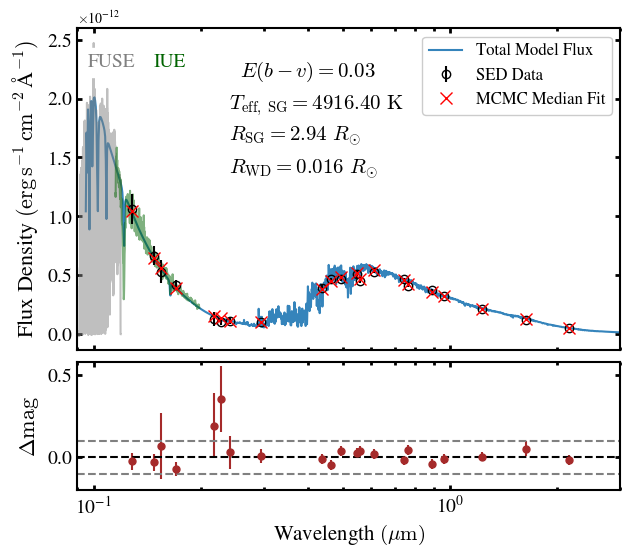

In [17]:
## Plot the figure in paper
fig = plt.figure(figsize=(7, 6))

gs = GridSpec(
    2, 1,
    height_ratios=[1, 0.4],   # top, bottom
    hspace=0.05             # vertical spacing
)

ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

filters = ['GALEX_FUV', 'GALEX_NUV', 
         'SDSS_g', 'SDSS_r', 'SDSS_i', 'SDSS_z', 'PS1_y', 
         '2MASS_J', '2MASS_H', '2MASS_Ks',
        "IUE/IUE.1250-1300", "IUE/IUE.1450-1500", "IUE/IUE.1675-1725", "IUE/IUE.2150-2200", "IUE/IUE.2395-2445", "IUE/IUE.2900-3000",
        ]
is_ab = [True, True, 
       True, True, True, True, True,
       False, False, False,
      True, True, True, True, True, True,
      ]


filters = ['GALEX_FUV', 'GALEX_NUV', 
         'SDSS_g', 'SDSS_r', 'SDSS_i', 'SDSS_z', 'PS1_y', 
         'Gaia_BP', 'Gaia_G', 'Gaia_RP',
         '2MASS_J', '2MASS_H', '2MASS_Ks',
        "IUE/IUE.1250-1300", "IUE/IUE.1450-1500", "IUE/IUE.1675-1725", "IUE/IUE.2150-2200", "IUE/IUE.2395-2445", "IUE/IUE.2900-3000",
        "Generic/Johnson.B", "Generic/Johnson.V"]
is_ab = [True, True, 
       True, True, True, True, True,
       False, False, False,
       False, False, False,
      True, True, True, True, True, True,
      True, True]

teff_sg = 4916.4
r_sg = 2.94
ebv = 0.03
r_wd = 0.016

data_flux, data_flux_err = get_band_flux_from_mag(mags_gaiasyn, mags_err_gaiasyn, filters = filters,
                                                  is_ab = is_ab)

wl1, flam1, bnd_fl1, bnd_wv1 = get_flux_model_spec(0, teff_sg, r_sg, r_wd, ebv, model = 'phoenix',
                                                  filters = filters,
                                                  is_ab = is_ab, save_dil_fact=True)

flam1 = downresolve_constant_R(wl1, flam1, 500)

syn_mags = get_band_mag_model_spec(0, teff_sg, r_sg, r_wd, ebv, model = 'phoenix',
                                                  filters = filters,
                                                  is_ab = is_ab)

wave_lim = [0.09, 3]

select = (wl1/1e4<wave_lim[1])&(wl1/1e4>wave_lim[0])

ax_top.plot(wl1[select]/1e4, flam1[select], alpha = 0.9, c='C0', label = 'Total Model Flux')
ax_top.set_xscale('log')
ax_top.set_xlim(wave_lim[0], wave_lim[1])

ax_top.plot(wave_uniform, flux_conv_uniform, alpha = 0.5, c='gray')
ax_top.plot(iue_data['WAVE'][0] / 1e4, iue_data['FLUX'][0], c='darkgreen', alpha = 0.5)


ax_top.errorbar(np.array(bnd_wv1)/1e4, data_flux, data_flux_err, zorder = 100, c='k', ls = 'None',
            mec = 'k', marker = 'o', label = 'SED Data', ms = 6, mfc = 'None')

ax_top.errorbar(np.array(bnd_wv1)/1e4, bnd_fl1, zorder = 100, c='red', ls = 'None',
            mec = 'red', marker = 'x', label = 'MCMC Median Fit', ms = 8)

ax_top.legend(fontsize = 12, framealpha = 1.0)

ax_top.tick_params(which='both',direction='in',top=True,right=True,labelsize=14,labelbottom = False, width=2)

ax_top.text(0.02, 0.88, 'FUSE', c='gray', transform=ax_top.transAxes, fontsize = 14,
        bbox=dict(facecolor='white', edgecolor='white', alpha=1.0))

ax_top.text(0.14, 0.88, 'IUE', c='darkgreen', transform=ax_top.transAxes, fontsize = 14,
        bbox=dict(facecolor='white', edgecolor='white', alpha=1.0))


ax_top.set_ylabel(r'Flux Density $\rm (erg\,s^{-1}\,cm^{-2}\,\AA^{-1})$', fontsize = 16)

ax_top.text(0.3, 0.85, r'$E(b-v)={:.2f}$'.format(ebv), fontsize = 15, transform=ax_top.transAxes)
ax_top.text(0.28, 0.75, r'$T_{{\rm eff,~SG}}={:.2f}~\rm K$'.format(teff_sg), fontsize = 15, transform=ax_top.transAxes)
ax_top.text(0.28, 0.65, r'$R_{{\rm SG}}={:.2f}~R_{{\odot}}$'.format(r_sg), fontsize = 15, transform=ax_top.transAxes)
ax_top.text(0.28, 0.55, r'$R_{{\rm WD}}={:.3f}~R_{{\odot}}$'.format(r_wd), fontsize = 15, transform=ax_top.transAxes)

ax_bot.errorbar(np.array(bnd_wv1)/1e4, (mags_gaiasyn - syn_mags), yerr = mags_err_gaiasyn, 
                c='brown', ls = 'None', ms = 5, marker = 'o')

ax_bot.tick_params(which='both',direction='in',top=True,right=True,labelsize=14,labelbottom = True, width=2)

ax_bot.set_xlabel(r'Wavelength $\rm (\mu m)$', fontsize = 15)

ax_bot.set_ylabel(r'$\Delta {\rm mag}$', fontsize = 16)

ax_bot.axhline(0.1, c='grey', linestyle = '--')
ax_bot.axhline(-0.1, c='grey', linestyle = '--')
ax_bot.axhline(0.0, c='k', linestyle = '--')

ax_bot.set_ylim(-0.2, 0.58)

#plt.savefig("./plots/a35_paper_plots/a35_sed_fit.png",dpi=200,bbox_inches='tight')

plt.show()


## With Eb-v Fixed

### MCMC

In [42]:
'''
filters = ['GALEX_FUV', 'GALEX_NUV', 
         'SDSS_g', 'SDSS_r', 'SDSS_i', 'SDSS_z', 'PS1_y', 
         '2MASS_J', '2MASS_H', '2MASS_Ks',
        "IUE/IUE.1250-1300", "IUE/IUE.1450-1500", "IUE/IUE.1675-1725", "IUE/IUE.2150-2200", "IUE/IUE.2395-2445", "IUE/IUE.2900-3000",
        ]
is_ab = [True, True, 
       True, True, True, True, True,
       False, False, False,
      True, True, True, True, True, True,
      ]
'''

filters = ['GALEX_FUV', 'GALEX_NUV', 
         'SDSS_g', 'SDSS_r', 'SDSS_i', 'SDSS_z', 'PS1_y', 
         'Gaia_BP', 'Gaia_G', 'Gaia_RP',
         '2MASS_J', '2MASS_H', '2MASS_Ks',
        "IUE/IUE.1250-1300", "IUE/IUE.1450-1500", "IUE/IUE.1675-1725", "IUE/IUE.2150-2200", "IUE/IUE.2395-2445", "IUE/IUE.2900-3000",
        "Generic/Johnson.B", "Generic/Johnson.V"]
is_ab = [True, True, 
       True, True, True, True, True,
       False, False, False,
       False, False, False,
      True, True, True, True, True, True,
      True, True]

#"Generic/Johnson.B", "Generic/Johnson.V"

#### Defining the log likelihood function (Equation 22 in paper) ######
def log_likelihood(all_pars, x, y, yerr):
    #Teff, radius_rsun, radius_rsun_wd, Ebv = all_pars
    Teff, radius_rsun, radius_rsun_wd = all_pars
    model = get_band_mag_model_spec(x, Teff, radius_rsun, radius_rsun_wd, Ebv=0.03, Z=0.0, model = 'phoenix',
                                   filters=filters,
                                   is_ab=is_ab)
    sigma2 = (yerr**2)
    loglike = -0.5 * np.nansum((y - model) ** 2 / sigma2)
    return loglike

def uniform_prior(x, a, b):
    if a<=x<=b:
        return -np.log(b-a)
    else:
        return -np.inf
    
def log_prior(all_pars):
    lp = 0
    Teff, radius_rsun, radius_rsun_wd = all_pars
    lp+=uniform_prior(Teff, 4000, 6000)
    lp+=uniform_prior(radius_rsun, 0.5, 10)
    lp+=uniform_prior(radius_rsun_wd, 0.01, 0.04)
    return lp

###### Generate the log probability #######
def log_probability(all_pars, x, y, yerr):
    lp = log_prior(all_pars)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(all_pars, x, y, yerr)

In [43]:
dummyx = 0

Teff_true = 4900
radius_rsun_true = 3
radius_rsun_wd_true = 0.03
true_param = np.array([Teff_true, radius_rsun_true, radius_rsun_wd_true])

pos = []
for i in range(20):
    rand_num = np.random.uniform(-0.1,0.1,3)
    pos_temp = true_param+(rand_num*true_param)
    pos = pos+[pos_temp.tolist()]
pos = np.array(pos)

nwalkers, ndim = pos.shape

with Pool(8) as pool:
    sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(dummyx, mags_gaiasyn, mags_err_gaiasyn),
    pool=pool)
    sampler.run_mcmc(pos, 2500, progress=True)


100%|███████████████████████████████████████| 2500/2500 [41:50<00:00,  1.00s/it]


In [44]:
flat_samples = sampler.get_chain(discard=200, thin=2, flat=True)
flat_samples_prob = sampler.get_log_prob(discard=200, thin=2, flat=True)

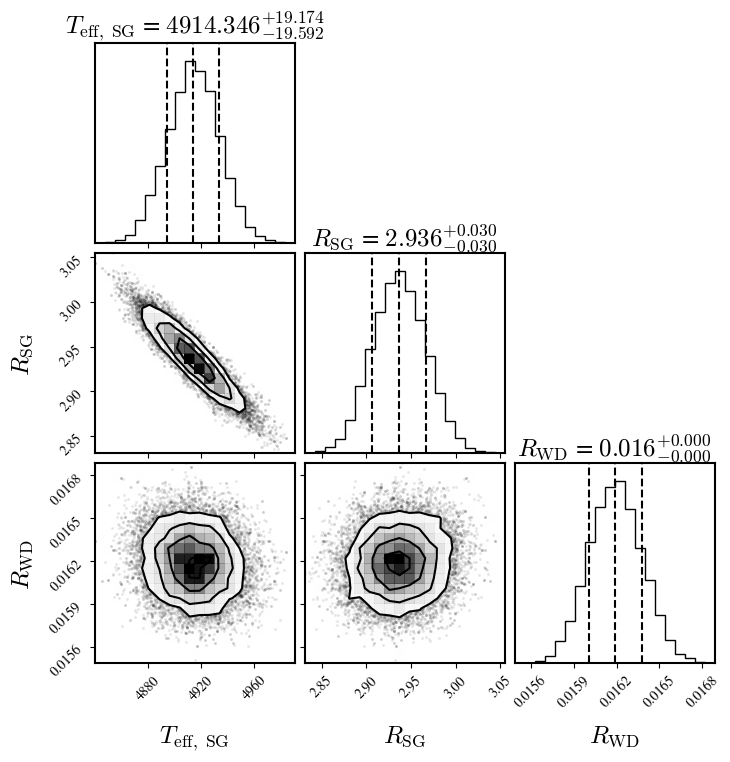

In [45]:
import corner

labels = [r"$T_{\rm eff,~SG}$", r"$R_{\rm SG}$", r"$R_{\rm WD}$", r"$Eb-v$", r"$Z$"]


fig = corner.corner(
    flat_samples, labels=labels, show_titles=True, plot_datapoints=True,quantiles=[0.16, 0.5, 0.84],
    label_kwargs=dict(fontsize=18),
    title_kwargs=dict(fontsize=18),
    title_fmt='.3f'
);

#plt.savefig("./plots/a35_paper_plots/a35_sed_fit_corner.png",dpi=200,bbox_inches='tight')

## With Eb-v Free

In [46]:
'''
filters = ['GALEX_FUV', 'GALEX_NUV', 
         'SDSS_g', 'SDSS_r', 'SDSS_i', 'SDSS_z', 'PS1_y', 
         '2MASS_J', '2MASS_H', '2MASS_Ks',
        "IUE/IUE.1250-1300", "IUE/IUE.1450-1500", "IUE/IUE.1675-1725", "IUE/IUE.2150-2200", "IUE/IUE.2395-2445", "IUE/IUE.2900-3000",
        ]
is_ab = [True, True, 
       True, True, True, True, True,
       False, False, False,
      True, True, True, True, True, True,
      ]
'''

filters = ['GALEX_FUV', 'GALEX_NUV', 
         'SDSS_g', 'SDSS_r', 'SDSS_i', 'SDSS_z', 'PS1_y', 
         'Gaia_BP', 'Gaia_G', 'Gaia_RP',
         '2MASS_J', '2MASS_H', '2MASS_Ks',
        "IUE/IUE.1250-1300", "IUE/IUE.1450-1500", "IUE/IUE.1675-1725", "IUE/IUE.2150-2200", "IUE/IUE.2395-2445", "IUE/IUE.2900-3000",
        "Generic/Johnson.B", "Generic/Johnson.V"]
is_ab = [True, True, 
       True, True, True, True, True,
       False, False, False,
       False, False, False,
      True, True, True, True, True, True,
      True, True]


#### Defining the log likelihood function (Equation 22 in paper) ######
def log_likelihood(all_pars, x, y, yerr):
    Teff, radius_rsun, radius_rsun_wd, Ebv = all_pars
    model = get_band_mag_model_spec(x, Teff, radius_rsun, radius_rsun_wd, Ebv = Ebv, Z=-0.2, model = 'phoenix',
                                   filters=filters,
                                   is_ab=is_ab)
    sigma2 = (yerr**2)
    loglike = -0.5 * np.nansum((y - model) ** 2 / sigma2)
    return loglike

def uniform_prior(x, a, b):
    if a<=x<=b:
        return -np.log(b-a)
    else:
        return -np.inf
    
def log_prior(all_pars):
    lp = 0
    Teff, radius_rsun, radius_rsun_wd, Ebv = all_pars
    lp+=uniform_prior(Teff, 4000, 6000)
    #lp+=uniform_prior(mass_msun, 0.8, 5)
    lp+=uniform_prior(radius_rsun, 0.5, 10)
    lp+=uniform_prior(radius_rsun_wd, 0.01, 0.04)
    #lp+=uniform_prior(distance_pc, 100, 300)
    lp+=uniform_prior(Ebv, 0.0, 2)
    #lp+=uniform_prior(Z, -0.25, 0.25)
    return lp

###### Generate the log probability #######
def log_probability(all_pars, x, y, yerr):
    lp = log_prior(all_pars)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(all_pars, x, y, yerr)

In [47]:
dummyx = 0

Teff_true = 4900
mass_msun_true = 2.5
radius_rsun_true = 2
radius_rsun_wd_true = 0.03
distance_pc_true = 166
Ebv_true = 0.02
Z_true = 0.001
true_param = np.array([Teff_true, radius_rsun_true, radius_rsun_wd_true, Ebv_true])

pos = []
for i in range(20):
    rand_num = np.random.uniform(-0.1,0.1,4)
    pos_temp = true_param+(rand_num*true_param)
    pos = pos+[pos_temp.tolist()]
pos = np.array(pos)

nwalkers, ndim = pos.shape

with Pool(8) as pool:
    sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(dummyx, mags_gaiasyn, mags_err_gaiasyn),
    pool=pool)
    sampler.run_mcmc(pos, 2500, progress=True)

'''
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(dummyx, mags_gaiasyn, mags_err_gaiasyn)
)
sampler.run_mcmc(pos, 2500, progress=True)
'''

100%|███████████████████████████████████████| 2500/2500 [42:39<00:00,  1.02s/it]


'\nsampler = emcee.EnsembleSampler(\n    nwalkers, ndim, log_probability, args=(dummyx, mags_gaiasyn, mags_err_gaiasyn)\n)\nsampler.run_mcmc(pos, 2500, progress=True)\n'

In [48]:
flat_samples = sampler.get_chain(discard=200, thin=2, flat=True)
flat_samples_prob = sampler.get_log_prob(discard=200, thin=2, flat=True)

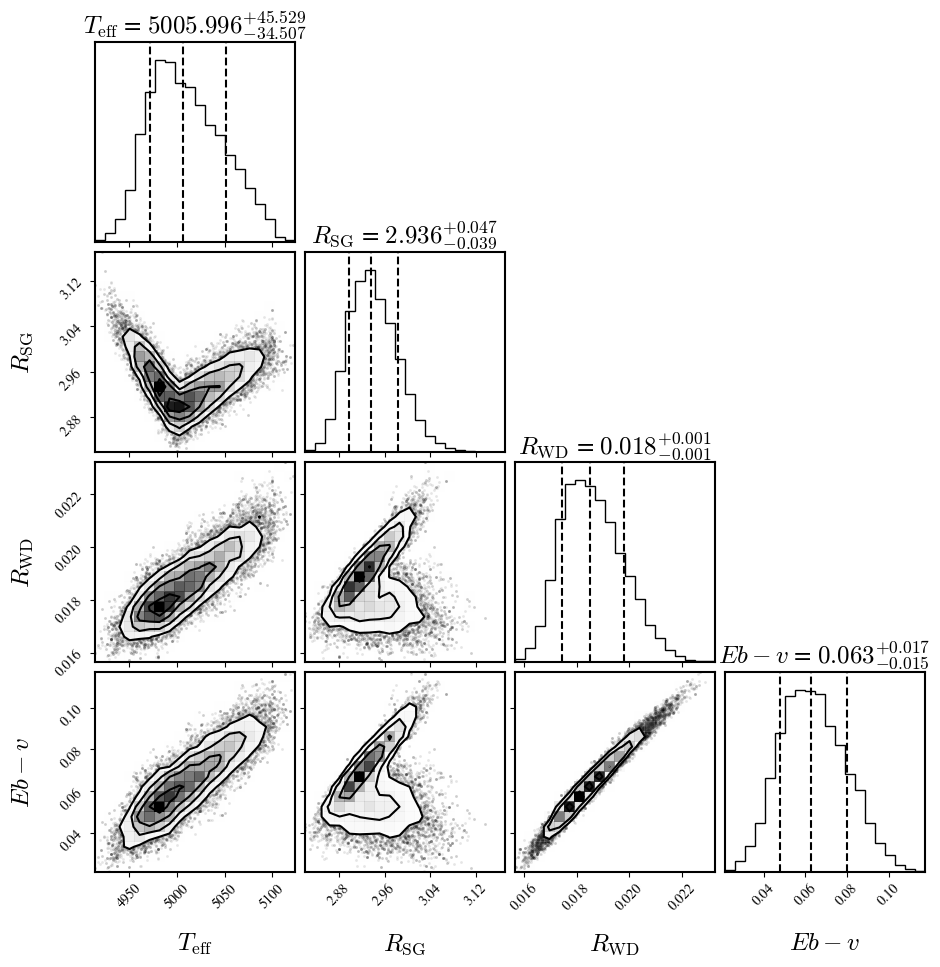

In [49]:
import corner

labels = [r"$T_{\rm eff}$", r"$R_{\rm SG}$", r"$R_{\rm WD}$", r"$Eb-v$", r"$Z$"]


fig = corner.corner(
    flat_samples, labels=labels, show_titles=True, plot_datapoints=True,quantiles=[0.16, 0.5, 0.84],
    label_kwargs=dict(fontsize=18),
    title_kwargs=dict(fontsize=18),
    title_fmt='.3f'
);

# The WD Mass Problem

In [21]:
## Forming the Interpolator among the TMAP models

teffs_tmap_kK = np.array([60, 70, 80, 90, 100])

tmap_fluxes = []

for teff_kK in teffs_tmap_kK:
    
    if teff_kK>=100:
        tmap_70kk = pd.read_csv('./a35/tmap_webpage/0{}000_7.50_H+He_0.600_0.400_00005-02000A.bin_0.1.gz'.format(teff_kK), skiprows=29, header = None,
                       delim_whitespace=True)
    else:
        tmap_70kk = pd.read_csv('./a35/tmap_webpage/00{}000_7.50_H+He_0.600_0.400_00005-02000A.bin_0.1.gz'.format(teff_kK), skiprows=29, header = None,
                           delim_whitespace=True)

    tmap_70kk = tmap_70kk[(tmap_70kk[0]>950)&(tmap_70kk[0]<1e5)]

    if teff_kK==60:
        tmap_wave = tmap_70kk[0].values
        
    tmap_flux = np.interp(tmap_wave, tmap_70kk[0].values, tmap_70kk[1].values/1e8)
        
    tmap_fluxes.append(tmap_flux)
    
tmap_fluxes = np.array(tmap_fluxes)

interp_func = interp1d(
    teffs_tmap_kK,
    tmap_fluxes,
    axis=0,
    kind='linear',
    bounds_error=False,   # allow outside range
    fill_value='extrapolate'  # or np.nan
)

In [31]:
## Load Miller Bertolami Tracks

filepath = "./miller_bertolami/0100_t03.dat.txt" 

models = []
tracks = {}

with open(filepath, "r") as f:
    lines = f.readlines()

i = 0
model_index = 0

while i < len(lines):
    line = lines[i].strip()

    # Detect model header line
    if line.startswith("# Initial Mass"):
        
        # Next line has numeric header info
        header_nums = re.findall(r"[-+]?\d*\.\d+|\d+", lines[i+1])
        init_mass = float(header_nums[0])
        final_mass = float(header_nums[1])
        n_points  = int(header_nums[2])

        # Advance to composition block
        i += 2

        # Skip until reaching the table header "#N ..."
        while i < len(lines) and not lines[i].strip().startswith("#N"):
            i += 1

        # Now i is at "#N ..."
        table_header = lines[i].strip().lstrip("#").split()
        i += 1

        # Read n_points numerical rows
        data_rows = []
        for k in range(n_points):
            parts = lines[i+k].split()
            data_rows.append(parts)

        # Convert to DataFrame
        df_track = pd.DataFrame(data_rows, columns=table_header)

        # Convert columns to numeric
        for col in df_track.columns:
            df_track[col] = pd.to_numeric(df_track[col], errors="ignore")

        # Store
        tracks[model_index] = df_track

        # Store summary
        models.append({
            "Model_Index": model_index,
            "Initial_Mass": init_mass,
            "Final_Mass": final_mass,
            "Num_Points": n_points
        })

        # Move pointer past the track
        i += n_points
        model_index += 1

    else:
        i += 1


# Summary DataFrame
models_df = pd.DataFrame(models)


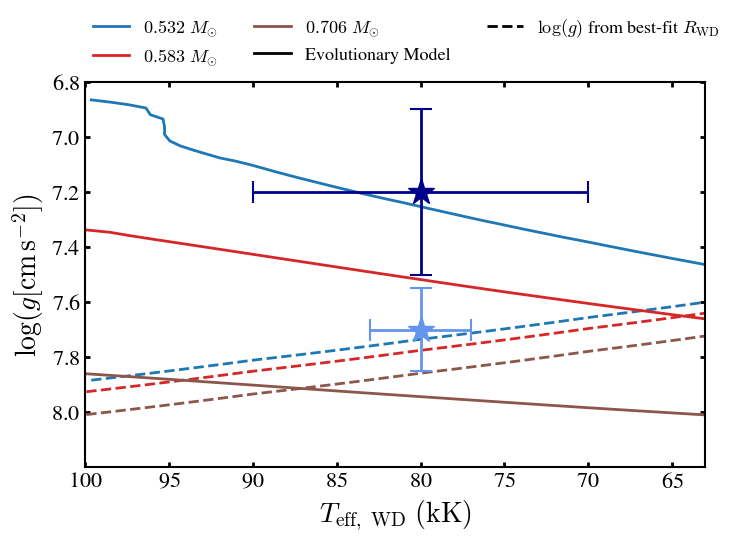

In [36]:
## Perform Calculations and Plot the Figure

iue_fluxes = np.array([1.066e-12, 6.675e-13, 4.204e-13])
iue_flux_errs = np.array([5.046e-14, 3.222e-14, 1.627e-14])

iue_flux_logs = -2.5*np.log10(iue_fluxes)
iue_flux_log_errs = (iue_flux_errs/iue_fluxes)*1.086

distance_pc = 165.75

fig = plt.figure('a',figsize=(8,5))

#cols = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8']
cols = ['C0', 'C1', 'C3', 'C2', 'C4', 'C5', 'C6', 'C7', 'C8']

#model_indices = [0, 3, 5]
model_indices = [0, 2, 5]

for i in range(len(tracks)):
    
    if i not in model_indices:
        continue
    
    track = tracks[i]
    
    select1 = (tracks[i]['Logg']<=8.5) & (tracks[i]['Logg']>=6.5)
    select2 = (tracks[i]['LogTeff']<=5) & (tracks[i]['LogTeff']>=4.78)
    
    select = select1 & select2
    
    track = track[select]
    
    plt.plot((10**track['LogTeff'])/1e3, track['Logg'], c=cols[i], linewidth = 2, label = r'${}~M_{{\odot}}$'.format(round(models_df.Final_Mass.values[i], 3)))
    
    
    bestfit_rads = []
    for teff in track['LogTeff']:
        
        tmap_flux = interp_func((10**teff)/1e3)

        tmap_flux_scaled_template = tmap_flux * ext.extinguish(tmap_wave/1e4 * u.um, Ebv=0.03) * np.pi * ((c.R_sun.cgs.value/(distance_pc*3.086e18))**2)

        mags_modelsyn = get_band_mag(tmap_wave, tmap_flux_scaled_template,
                                        filters = [
                                                  "IUE/IUE.1250-1300", "IUE/IUE.1450-1500", "IUE/IUE.1675-1725"],
                                                  is_ab = [
                                                          True, True, True])

        mags_modelsyn = np.array(mags_modelsyn)

        log10_sc_fac = np.sum((mags_modelsyn - iue_flux_logs)/(iue_flux_log_errs ** 2))/np.sum(1/(iue_flux_log_errs ** 2))

        bestfit_rad = np.sqrt(10**(0.4*log10_sc_fac))

        bestfit_rads.append(bestfit_rad)

    bestfit_rads = np.array(bestfit_rads)
            
    bestfit_loggs = np.log10(6.67430e-8 * (track['Mstar'] * 1.98847e33) / (bestfit_rads * 6.957e10)**2)
    
    plt.plot((10**track['LogTeff'])/1e3, bestfit_loggs, c=cols[i], linestyle = '--', linewidth = 2)
    
plt.errorbar(80, 7.2, xerr = 10, yerr = 0.3, marker = '*', c='darkblue', ms = 20, elinewidth = 2, zorder = 100,
            capsize=8, capthick=1.5)
plt.errorbar(80, 7.7, xerr = 3, yerr = 0.15, marker = '*', c='cornflowerblue', ms = 20, elinewidth = 2, zorder = 100,
            capsize=8, capthick=1.5)
    
plt.ylim(8.199, 6.8)
plt.xlim(100, 63)

plt.gca().tick_params(which='both',direction='in',top=True,right=True,labelsize=16,labelbottom = True, width=2)

plt.plot(0,0,linestyle = '-', linewidth = 2, c = 'k', label = r'Evolutionary Model')
plt.plot(0,0,linestyle = '--', linewidth = 2, c = 'k', label = r'$\log(g)$ from best-fit $R_{\rm WD}$')

plt.gca().set_xlabel(r'${T_{\rm eff,~WD}~\rm(kK)}$', fontsize=20)
plt.gca().set_ylabel(r'$\log(g[{\rm cm\,s^{-2}}])$', fontsize=20)

plt.legend(loc = (0, 1.02), ncols = 3, fontsize = 13, framealpha = 0)

plt.savefig("./plots/a35_paper_plots/a35_millerb_compare.png",dpi=300,bbox_inches='tight')
